In [26]:
import numpy as np
import pandas as pd 
from scipy.integrate import simps
from scipy.integrate import trapezoid
from prettytable import PrettyTable
from prettytable import from_csv
from prettytable import from_html

import matplotlib.pyplot as plt
from lightkurve import search_lightcurve 
import lightkurve as lk

In [27]:

#fl129=pd.read_csv('paola_flares1.csv') #lendo os flares 
tess_f = pd.read_csv('tess_functionx1.csv') #lendo os arquivos da função de resposta
#df = pd.DataFrame(fl129)
tf = pd.DataFrame(tess_f)

nm= np.array(tf["nm"]) # comprimento de onda em nm
ry= np.array(tf["ry"]) # tess function response

In [28]:
#Energia da flare
from PyAstronomy.pyasl import planck

#Mudança nm para cm e metro 
nm_metros = nm*(1e-9) #de nm para metros 
nm_cm = nm*(1e-7) #de nm para cm 


#Constantes importantes 
Teff= 3700# temperatura efetiva au mic
Tflare=10000# temperatura flare
raio=0.75*6.957e+10 # raio solar cm
sb1=5.67051e-5 #ergs cm-2*s-1*K-4


###########################
#Calculo da função de Planck
# Essa função (Bs=planck(Teff,lam=nm_metros)) da em [W/(m**2 m)] então
Bs=planck(Teff,lam=nm_metros)*1e-7 #multiplicação de *1e-7 para converter erg/(cm**2*A*s)
Bf=planck(Tflare,lam=nm_metros)*1e-7 #multiplicação de *1e-7 para converter erg/(cm**2*A*s)

In [29]:
import numpy as np

# Primeiro vetor
flux_flarex1 = np.array([1.00086045, 1.00183103, 1.00206079, 1.00263879, 1.00330608, 1.00338014,
                   1.00703221, 1.01164483, 1.02368899, 1.03272764, 1.04211239, 1.04385495,
                   1.03726084, 1.03186727, 1.02651494, 1.02442708, 1.02480385, 1.02428004,
                   1.02576579, 1.02426274, 1.02312803, 1.02326148, 1.02397803, 1.02236659,
                   1.02103553, 1.02066205, 1.01996238, 1.01827854, 1.01676864, 1.01720991,
                   1.01639638, 1.01628852, 1.0151288,  1.01554551, 1.01412919, 1.01417155,
                   1.01352122, 1.0140531,  1.01275231, 1.01231766, 1.01294956, 1.01178062,
                   1.01201516, 1.01094148, 1.01272053, 1.01159559, 1.01120683, 1.01158503,
                   1.01166065, 1.01083221, 1.01065495, 1.01068133, 1.01011422, 1.00933227,
                   1.01012894, 1.0101335,  1.00961765, 1.00886574, 1.0094719,  1.00787732,
                   1.0092285,  1.00880409, 1.00823221, 1.00857953, 1.00762435, 1.00858817,
                   1.00720438, 1.00712053, 1.0072176,  1.00796826, 1.00635436, 1.00717333,
                   1.00733801, 1.00580887, 1.005265,   1.0067403,  1.00585247, 1.00683716,
                   1.00623821, 1.00659233, 1.00735575, 1.00690117, 1.00637387, 1.00605152,
                   1.00614012, 1.00529187, 1.0057918,  1.00636542, 1.00515842, 1.00499654,
                   1.00567268, 1.00546216, 1.00503584, 1.0052854,  1.00414933, 1.0055791,
                   1.00399666, 1.00565629, 1.00457781, 1.00420132, 1.00503092, 1.00494939,
                   1.00398978, 1.00503553, 1.00481451, 1.00458622, 1.00402648, 1.00298376,
                   1.0043327,  1.00394751, 1.00365758, 1.00394136, 1.00374371, 1.00432257,
                   1.00404564, 1.00411279, 1.002772,   1.00341596, 1.00460109, 1.00446377,
                   1.00410528, 1.00497626, 1.00425496, 1.00459013, 1.00402109, 1.00459185,
                   1.00330662, 1.0040121,  1.00485232, 1.00379135, 1.00286095, 1.00460205,
                   1.00354536, 1.00480025, 1.00428214, 1.00365193, 1.00358734, 1.00369717,
                   1.00339555, 1.00299425, 1.00388074, 1.00343962, 1.00271309, 1.00390731,
                   1.00291571, 1.00215697, 1.00261018, 1.00291781, 1.00330426, 1.00252501,
                   1.00209485, 1.00213887, 1.00312146, 1.00285608, 1.00212762, 1.00165788,
                   1.00331984, 1.00219971, 1.00196712, 1.00218259, 1.00050458, 1.00231522,
                   1.00216895, 1.004219,   1.00260442, 1.00256295, 1.00201655, 1.00162622,
                   1.00227306, 1.00211177, 1.00260135, 1.00277914])


# Segundo vetor
tempo_flarex1 =   np.array([2037.67284569, 2037.67307718, 2037.67330867, 2037.67354016, 2037.67377164,
                   2037.67400313, 2037.67423462, 2037.67446611, 2037.6746976, 2037.67492909,
                   2037.67516057, 2037.67539206, 2037.67562355, 2037.67585504, 2037.67608653,
                   2037.67631802, 2037.6765495, 2037.67678099, 2037.67701248, 2037.67747546,
                   2037.67770695, 2037.67793843, 2037.67816992, 2037.6786329, 2037.67886439,
                   2037.67909587, 2037.67932736, 2037.67955885, 2037.67979034, 2037.68002183,
                   2037.68025332, 2037.6804848, 2037.68094778, 2037.68117927, 2037.68141076,
                   2037.68164225, 2037.68187373, 2037.68210522, 2037.68233671, 2037.6825682,
                   2037.68279969, 2037.68303118, 2037.68326266, 2037.68349415, 2037.68372564,
                   2037.68395713, 2037.68418862, 2037.6844201, 2037.68465159, 2037.68488308,
                   2037.68511457, 2037.68534606, 2037.68557755, 2037.68580903, 2037.68604052,
                   2037.68627201, 2037.6865035, 2037.68673499, 2037.68696648, 2037.68719796,
                   2037.68742945, 2037.68766094, 2037.68789243, 2037.68812392, 2037.68835541,
                   2037.68858689, 2037.68881838, 2037.68951285, 2037.68974433, 2037.68997582,
                   2037.69020731, 2037.6904388, 2037.69067029, 2037.69090178, 2037.69113326,
                   2037.69136475, 2037.69159624, 2037.69182773, 2037.69205922, 2037.69229071,
                   2037.69252219, 2037.69275368, 2037.69298517, 2037.69321666, 2037.69344815,
                   2037.69367964, 2037.69391112, 2037.69414261, 2037.6943741, 2037.69460559,
                   2037.69483708, 2037.69506856, 2037.69530005, 2037.69553154, 2037.69576303,
                   2037.69599452, 2037.69622601, 2037.69645749, 2037.69668898, 2037.69692047,
                   2037.69715196, 2037.69738345, 2037.69761494, 2037.69784642, 2037.69807791,
                   2037.6983094, 2037.69854089, 2037.69877238, 2037.69900387, 2037.69923535,
                   2037.69946684, 2037.69969833, 2037.69992982, 2037.70016131, 2037.70039279,
                   2037.70062428, 2037.70085577, 2037.70108726, 2037.70131875, 2037.70155024,
                   2037.70178172, 2037.70201321, 2037.7022447, 2037.70247619, 2037.70270768,
                   2037.70293917, 2037.70317065, 2037.70340214, 2037.70363363, 2037.70386512,
                   2037.7043281, 2037.70455958, 2037.70479107, 2037.70502256, 2037.70548554,
                   2037.70571702, 2037.70594851, 2037.70618, 2037.70641149, 2037.70664298,
                   2037.70687447, 2037.70710595, 2037.70756893, 2037.70780042, 2037.70803191,
                   2037.7082634, 2037.70849488, 2037.70872637, 2037.70895786, 2037.70918935,
                   2037.70942084, 2037.70965232, 2037.70988381, 2037.7101153, 2037.71034679,
                   2037.71057828, 2037.71080977, 2037.71104125, 2037.71127274, 2037.71150423,
                   2037.71173572, 2037.71196721, 2037.7121987, 2037.71243018, 2037.71266167,
                   2037.71289316, 2037.71312465, 2037.71335614, 2037.71358763, 2037.71381911,
                   2037.7140506, 2037.71428209])



4.822946761834555e+33


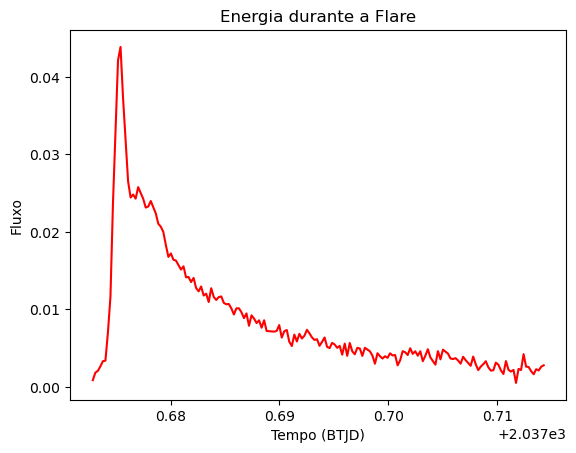

In [30]:

# Fluxo relativo da estrela (valor mínimo de fluxo na região da flare)
f_rel_estrela = np.min(flux_flarex1)

# Calcular a amplitude da flare (diferença entre o fluxo máximo da flare e o fluxo relativo da estrela)
amplitude_flare2 =  flux_flarex1 - 1
print()

# Integral
Aflare = amplitude_flare2*np.pi*(raio**2) #(cm^2)

Aflare1 = simps(ry*Bs,nm_cm)/simps(ry*Bf,nm_cm)

# Área total da flare
Atotal = Aflare*Aflare1 #cm^2

# Luminosidade da flare
L = sb1*(Tflare**4)*Atotal #erg/s

# Energia bolométrica do flare

E1 = simps(L,tempo_flarex1*86400) #erg


#print(amplitude_flare2)
print(E1)

# Criação do gráfico do tempo_flare em relação ao fluxo_flare
plt.plot(tempo_flarex1, amplitude_flare2, 'r-')
plt.xlabel('Tempo (BTJD)')
plt.ylabel('Fluxo')
plt.title('Energia durante a Flare')
plt.show()

In [37]:
flux_flare2 = [0.99996351, 1.00127085, 1.00265137, 1.00684529, 1.00833398, 1.00918918,
                   1.01065379, 1.01250642, 1.01077007, 1.00975937, 1.00944158, 1.00881618,
                   1.00882272, 1.00805118, 1.0069151, 1.00659351, 1.00408409, 1.00538129,
                   1.00553114, 1.00369636, 1.0053454, 1.00525929, 1.00272095, 1.00361731,
                   1.00365315, 1.00255861, 1.00297714, 1.00147323, 1.00167325, 1.0039657,
                   1.0014905, 1.0019452, 1.00172933, 1.00208605, 1.00276104, 1.00237553,
                   1.00120818, 1.00235726, 1.00266777, 1.00241212, 1.00243867, 1.00246035,
                   1.00299579, 1.00196269, 1.00198995, 1.00263096, 1.002016, 1.00193069,
                   1.00119688, 1.00152943, 1.00145985, 1.00147816, 1.00170856, 1.00213986,
                   1.00098254, 1.00120455, 1.0006484, 1.00234832, 1.00093707, 1.00009156,
                   1.00095032, 1.00128486, 1.0012202, 1.00080239]

tempo_flare2 = [2039.18168504, 2039.18214801, 2039.1823795, 2039.18261099, 2039.18284248,
                   2039.18307397, 2039.18330545, 2039.18376843, 2039.18399992, 2039.18446289,
                   2039.18469438, 2039.18492587, 2039.18515736, 2039.18538884, 2039.18562033,
                   2039.18585182, 2039.18608331, 2039.1863148, 2039.18654628, 2039.18677777,
                   2039.18700926, 2039.18724075, 2039.18747224, 2039.18770372, 2039.18793521,
                   2039.1881667, 2039.18839819, 2039.18862968, 2039.18886116, 2039.18909265,
                   2039.18932414, 2039.18955563, 2039.18978711, 2039.1900186, 2039.19025009,
                   2039.19048158, 2039.19071307, 2039.19094455, 2039.19140753, 2039.19163902,
                   2039.19187051, 2039.19210199, 2039.19233348, 2039.19256497, 2039.19279646,
                   2039.19302795, 2039.19325943, 2039.19349092, 2039.19372241, 2039.1939539,
                   2039.19418538, 2039.19441687, 2039.19464836, 2039.19487985, 2039.19511134,
                   2039.19534282, 2039.19557431, 2039.1958058, 2039.19603729, 2039.19626878,
                   2039.19650026, 2039.19673175, 2039.19696324, 2039.19719473]


[2039.18168504 2039.18214801 2039.1823795  2039.18261099 2039.18284248
 2039.18307397 2039.18330545 2039.18376843 2039.18399992 2039.18446289
 2039.18469438 2039.18492587 2039.18515736 2039.18538884 2039.18562033
 2039.18585182 2039.18608331 2039.1863148  2039.18654628 2039.18677777
 2039.18700926 2039.18724075 2039.18747224 2039.18770372 2039.18793521
 2039.1881667  2039.18839819 2039.18862968 2039.18886116 2039.18909265
 2039.18932414 2039.18955563 2039.18978711 2039.1900186  2039.19025009
 2039.19048158 2039.19071307 2039.19094455 2039.19140753 2039.19163902
 2039.19187051 2039.19210199 2039.19233348 2039.19256497 2039.19279646
 2039.19302795 2039.19325943 2039.19349092 2039.19372241 2039.1939539
 2039.19418538 2039.19441687 2039.19464836 2039.19487985 2039.19511134
 2039.19534282 2039.19557431 2039.1958058  2039.19603729 2039.19626878
 2039.19650026 2039.19673175 2039.19696324 2039.19719473]
[0.99996351 1.00127085 1.00265137 1.00684529 1.00833398 1.00918918
 1.01065379 1.01250642 1

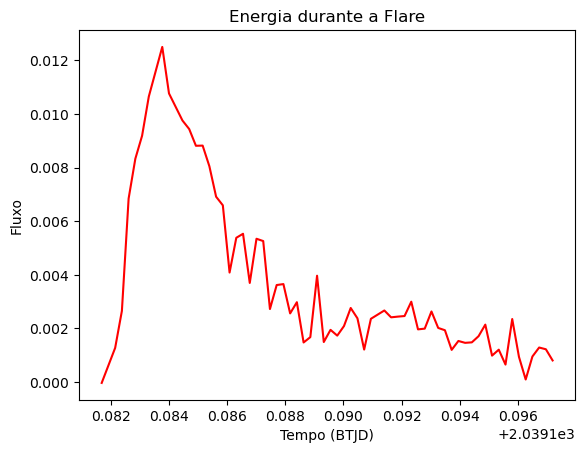

In [38]:
tempo_flare2 = np.array(tempo_flare2)
fluxo_flare2 = np.array(flux_flare2)

print(tempo_flare2), print(fluxo_flare2)
# Fluxo relativo da estrela (valor mínimo de fluxo na região da flare)
f_rel_estrela = np.min(flux_flare2)

# Calcular a amplitude da flare (diferença entre o fluxo máximo da flare e o fluxo relativo da estrela)
amplitude_flare1 =  fluxo_flare2 - 1
print()

# Integral
Aflare = amplitude_flare1*np.pi*(raio**2) #(cm^2)

Aflare1 = simps(ry*Bs,nm_cm)/simps(ry*Bf,nm_cm)

# Área total da flare
Atotal = Aflare*Aflare1 #cm^2

# Luminosidade da flare
L = sb1*(Tflare**4)*Atotal #erg/s

# Energia bolométrica do flare

E1 = simps(L,tempo_flare2*86400) #erg


#print(amplitude_flare2)
print(E1)

# Criação do gráfico do tempo_flare em relação ao fluxo_flare
plt.plot(tempo_flare2, amplitude_flare1, 'r-')
plt.xlabel('Tempo (BTJD)')
plt.ylabel('Fluxo')
plt.title('Energia durante a Flare')
plt.show()